In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-01-13_14-59-25/saved/checkpoint-epoch500.npy",
                                                            "+experiment=pvae_vh16_ovis", "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [5]:
metrics

{'loss': np.float32(48866.27), 'log_w': np.float32(-50320.125)}

In [6]:
for data, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 16, 16)
    break

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:72: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


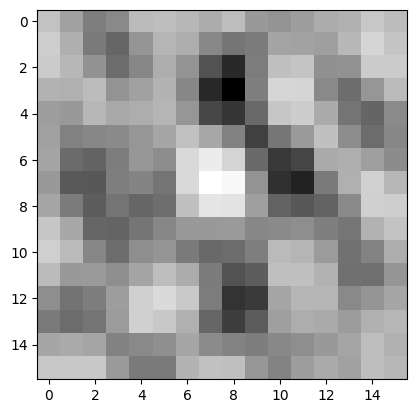

In [7]:
plt.imshow(recons[0].squeeze(), cmap="Greys_r")

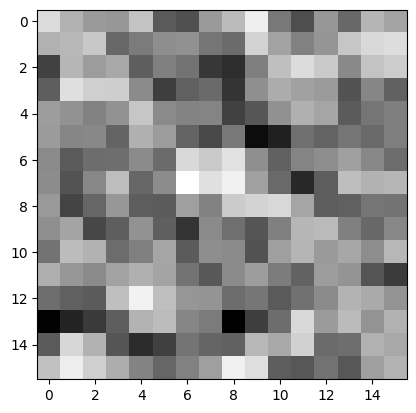

In [8]:
plt.imshow(data[0].squeeze(), cmap="Greys_r")

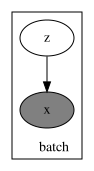

In [9]:
objects['monad'].render_model()

In [10]:
def r2(squared_errors, squared_data_residuals):
    return 1.0 - squared_errors / (squared_data_residuals + jnp.finfo("float64").eps)

def residuals(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    squared_data_residuals = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return squared_errors, squared_data_residuals

def sparsity(zs):
    return (zs == 0).mean(axis=(0, 2))

In [11]:
portion_zeros = []
squared_errors, squared_data_residuals = 0., 0.

for data, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 16, 16)
    errs, res = residuals(data, recons)
    portion_zeros.append(sparsity(traces["z"]))
    squared_errors += errs
    squared_data_residuals += res

portion_zeros = jnp.concatenate(portion_zeros, axis=0).mean()

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:72: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:72: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


In [12]:
portion_zeros

Array(0.8451222, dtype=float32)

In [13]:
r2(squared_errors, squared_data_residuals)

Array(0.05334622, dtype=float32)